In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load the Titanic dataset into a Pandas DataFrame
titanic = sns.load_dataset('titanic')

In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
column_nan_count = (titanic.isnull().sum())
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
missing_data = pd.DataFrame({
    'Missing Count': titanic.isnull().sum(),
    'Percentage (%)': (titanic.isnull().sum() / len(titanic)) * 100
})

# Optional: sort it so the columns with the missing data float to the top
missing_table = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
print(missing_table.to_string())

             Missing Count  Percentage (%)
deck                   688       77.216611
age                    177       19.865320
embarked                 2        0.224467
embark_town              2        0.224467


In [32]:
titanic['age']


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

Age is likely Missing at Random (MAR). The probability of a passenger's age being missing correlates systematically with other observed variables in the dataset, specifically passenger class (pclass); third-class passengers had a significantly higher rate of unrecorded ages than first-class passengers.

In [31]:
titanic['embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: object

Embarked is likely Missing Completely at Random (MCAR). With only 2 missing values out of 891 records (0.22%), the missingness is statistically negligible and exhibits no observable pattern across ticket fare, class, or survival, indicating a random clerical omission.

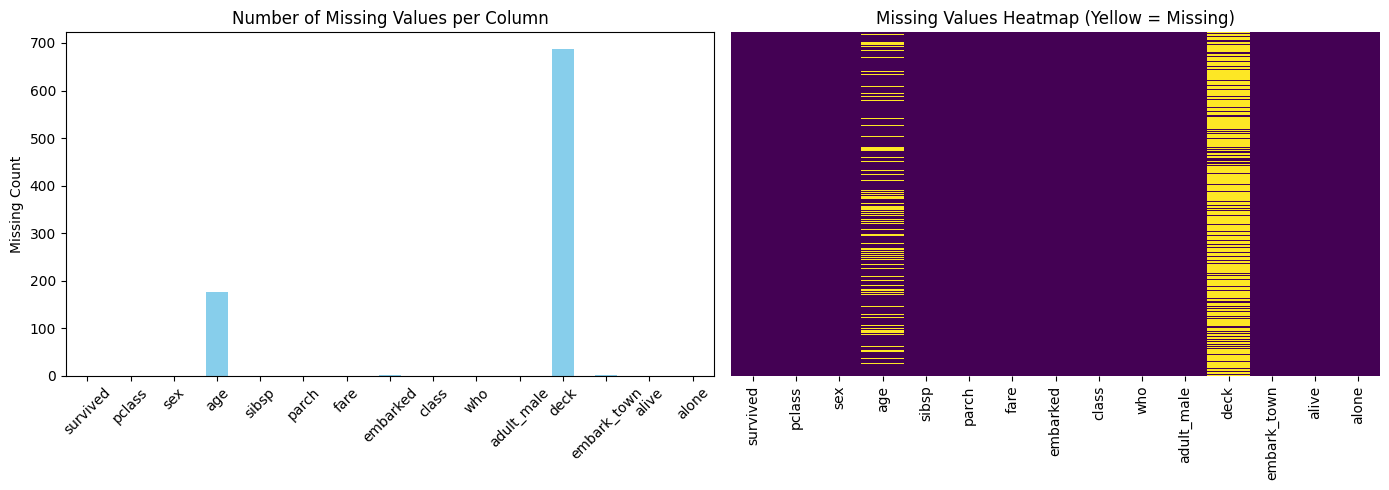

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar Plot
titanic.isnull().sum().plot(kind='bar', color='skyblue', ax=axes[0])
axes[0].set_title("Number of Missing Values per Column")
axes[0].set_ylabel("Missing Count")
axes[0].tick_params(axis='x', rotation=45)

# Right: Heatmap
sns.heatmap(titanic.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[1])
axes[1].set_title("Missing Values Heatmap (Yellow = Missing)")

plt.tight_layout()
plt.show()